In [ ]:
%reload_ext autoreload
%autoreload 2

%matplotlib inline

import os
import sys
from pathlib import Path

import numpy as np
from scipy.stats import lognorm
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name in {"notebooks", "physics"}:
    os.chdir("..")

project_root = str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"CWD: {Path.cwd()}")

CWD: c:\Users\reymo\quant-portfolio


Analytical Price: 8.0214
Monte Carlo Price: 8.0416
Pricing Error: 0.0203


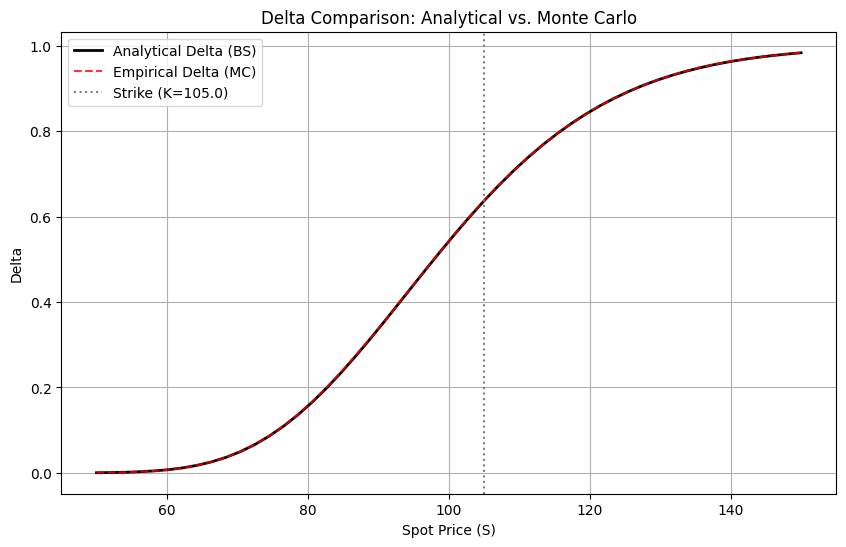

In [ ]:
from src.physics.analytics import BlackScholesAnalytical as BSA


# 1. Monte Carlo Engine Functions (Placeholders for your actual engine)
def monte_carlo_call(S, K, T, r, sigma, N_paths=100000, seed=42):
    """Calculates MC price using a fixed seed for reproducibility."""
    np.random.seed(seed)
    Z = np.random.standard_normal(N_paths)
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoffs = np.maximum(ST - K, 0)
    return np.exp(-r * T) * np.mean(payoffs)

def monte_carlo_delta(S, K, T, r, sigma, N_paths=100000, epsilon=0.01):
    """Calculates empirical Delta using central finite differences."""
    # Using the same seed inside monte_carlo_call ensures Common Random Numbers (CRN),
    # which isolates the effect of the epsilon shift and reduces variance.
    price_up = monte_carlo_call(S + epsilon, K, T, r, sigma, N_paths)
    price_down = monte_carlo_call(S - epsilon, K, T, r, sigma, N_paths)
    return (price_up - price_down) / (2 * epsilon)

# 2. Define State Parameters
S = 100.0
K = 105.0
T = 1.0
r = 0.05
sigma = 0.2

# 3. Price Validation
oracle = BSA(S, K, T, r, sigma)
bs_price = oracle.call_price()
mc_price = monte_carlo_call(S, K, T, r, sigma)

print(f"Analytical Price: {bs_price:.4f}")
print(f"Monte Carlo Price: {mc_price:.4f}")
print(f"Pricing Error: {mc_price - bs_price:.4f}")

# 4. Delta Vectorization and Computation
S_range = np.linspace(50, 150, 50)
bs_deltas = []
mc_deltas = []

for s in S_range:
    # Analytical
    temp_oracle = BSA(s, K, T, r, sigma)
    bs_deltas.append(temp_oracle.call_delta())
    
    # Empirical
    mc_deltas.append(monte_carlo_delta(s, K, T, r, sigma))

# 5. Visualization
plt.figure(figsize=(10, 6))
plt.plot(S_range, bs_deltas, label='Analytical Delta (BS)', color='black', linewidth=2)
plt.plot(S_range, mc_deltas, label='Empirical Delta (MC)', color='red', linestyle='--', alpha=0.8)
plt.axvline(x=K, color='grey', linestyle=':', label=f'Strike (K={K})')
plt.title('Delta Comparison: Analytical vs. Monte Carlo')
plt.xlabel('Spot Price (S)')
plt.ylabel('Delta')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 1. Setup Initial Parameters
S_0 = 117.0
S_1 = 118.0
K = 105.0
T = 0.5
r = 0.05
sigma = 0.20
dS = S_1 - S_0

# 2. Instantiate and calculate base metrics
bs = BSA(S=S_0, K=K, T=T, r=r, sigma=sigma)

P_0 = bs.call_price()
delta = bs.call_delta()
gamma = bs.call_gamma()

# 3. Calculate new actual price 
# Here we use the @property architecture to update S dynamically
bs.S = S_1
P_1 = bs.call_price()

# 4. Compute Approximations
actual_change = P_1 - P_0
delta_approx = delta * dS
gamma_approx = delta_approx + 0.5 * gamma * (dS**2)

# 5. Output Results
print(f"Actual BS Price Change:      {actual_change:.6f}")
print(f"Delta Approximation Only:    {delta_approx:.6f}")
print(f"Delta + Gamma Approximation: {gamma_approx:.6f}")
print("-" * 45)
print(f"Error (Delta Only):          {abs(actual_change - delta_approx):.6f}")
print(f"Error (Delta + Gamma):       {abs(actual_change - gamma_approx):.6f}")

Actual BS Price Change:      0.851444
Delta Approximation Only:    0.844392
Delta + Gamma Approximation: 0.851611
---------------------------------------------
Error (Delta Only):          0.007053
Error (Delta + Gamma):       0.000167


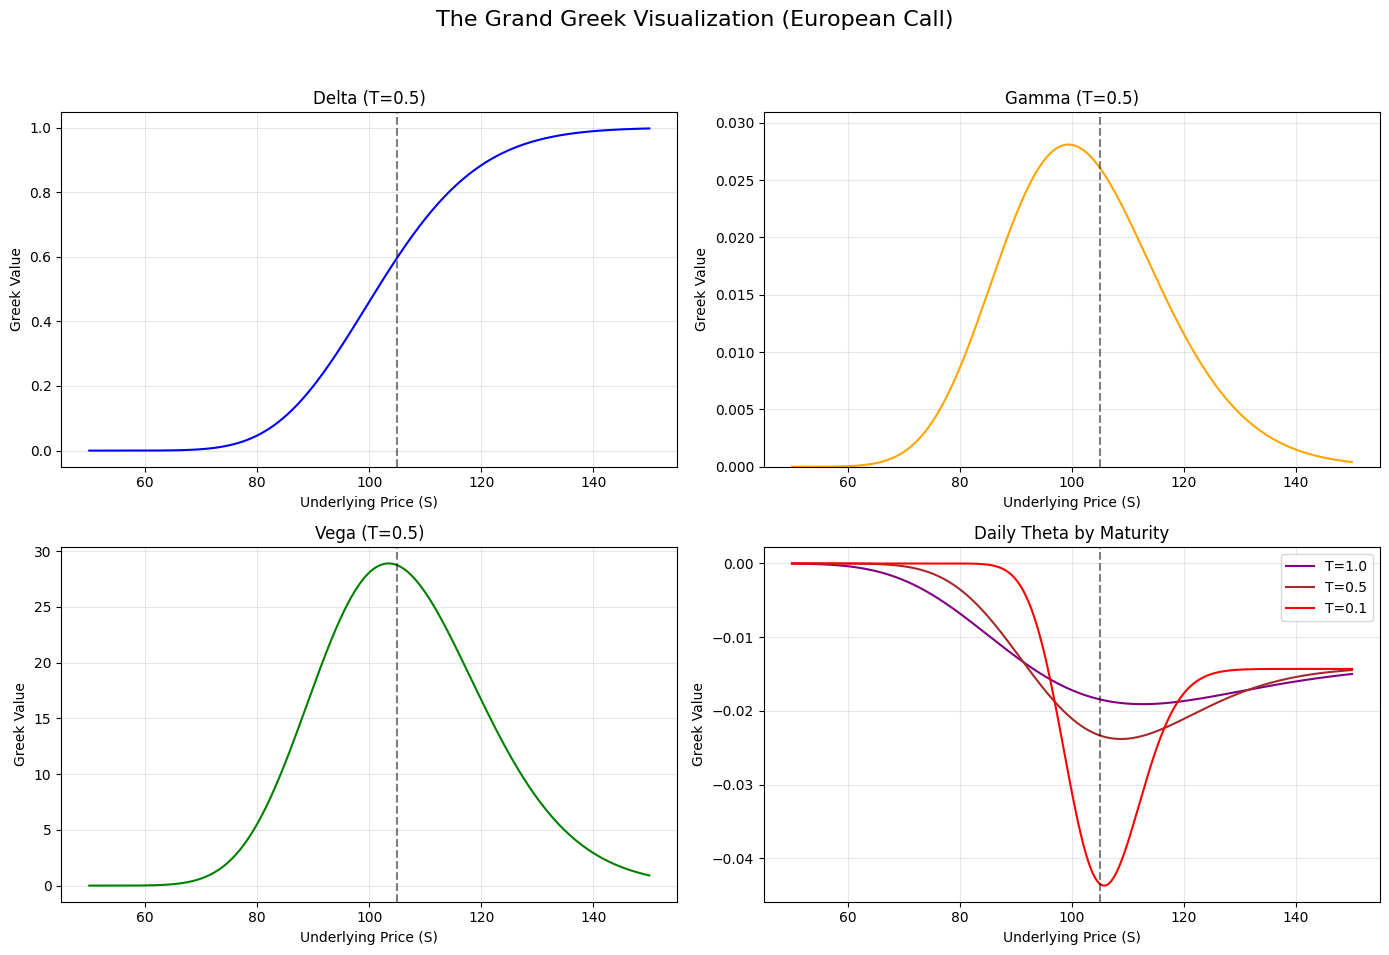

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Generation
K = 105.0
r = 0.05
sigma = 0.2
T = 0.5
S = np.linspace(50, 150, 2000)

delta = [BSA(S=s, K=K, T=T, r=r, sigma=sigma).call_delta() for s in S]
gamma = [BSA(S=s, K=K, T=T, r=r, sigma=sigma).call_gamma() for s in S]
vega =  [BSA(S=s, K=K, T=T, r=r, sigma=sigma).call_vega() for s in S]

theta_10 = [BSA(S=s, K=K, T=1.0, r=r, sigma=sigma).call_theta(daily=True) for s in S]
theta_05 = [BSA(S=s, K=K, T=0.5, r=r, sigma=sigma).call_theta(daily=True) for s in S]
theta_01 = [BSA(S=s, K=K, T=0.1, r=r, sigma=sigma).call_theta(daily=True) for s in S]

# 2. Visualization Setup
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('The Grand Greek Visualization (European Call)', fontsize=16)

# Top Left: Delta
axes[0, 0].plot(S, delta, color='blue')
axes[0, 0].set_title(f'Delta (T={T})')
axes[0, 0].axvline(K, color='k', linestyle='--', alpha=0.5)

# Top Right: Gamma
axes[0, 1].plot(S, gamma, color='orange')
axes[0, 1].set_title(f'Gamma (T={T})')
axes[0, 1].axvline(K, color='k', linestyle='--', alpha=0.5)
axes[0, 1].set_ylim(0, np.max(gamma) * 1.1)  # Graceful peak handling

# Bottom Left: Vega
axes[1, 0].plot(S, vega, color='green')
axes[1, 0].set_title(f'Vega (T={T})')
axes[1, 0].axvline(K, color='k', linestyle='--', alpha=0.5)

# Bottom Right: Theta
axes[1, 1].plot(S, theta_10, label='T=1.0', color='purple')
axes[1, 1].plot(S, theta_05, label='T=0.5', color='brown')
axes[1, 1].plot(S, theta_01, label='T=0.1', color='red')
axes[1, 1].set_title('Daily Theta by Maturity')
axes[1, 1].axvline(K, color='k', linestyle='--', alpha=0.5)
axes[1, 1].legend()

# Global formatting
for ax in axes.flat:
    ax.set_xlabel('Underlying Price (S)')
    ax.set_ylabel('Greek Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# 1. Cast lists to numpy arrays
delta_arr = np.array(delta)
gamma_arr = np.array(gamma)

# 2. Calculate annualized Theta for T=0.5 (daily=False)
theta_annual_05 = np.array([BSA(S=s, K=K, T=T, r=r, sigma=sigma).call_theta(daily=False) for s in S])

3D Surface Plot (Surface of Delta)

<>:30: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:30: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\reymo\AppData\Local\Temp\ipykernel_27720\2578713709.py:30: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax.set_ylabel('Implied Volatility ($\sigma$)')


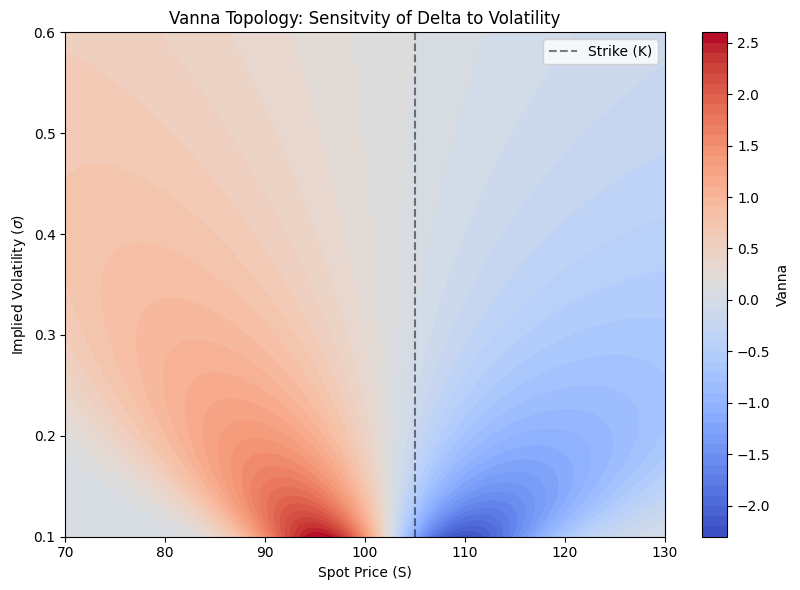

In [ ]:
from matplotlib import cm

K = 105.0
r = 0.05

S_array = np.linspace(70, 130, 100)
T_array = np.linspace(0.01, 1.0, 100)
sigma_array = np.linspace(0.1, 0.6, 100)

S_mesh_delta, T_mesh = np.meshgrid(S_array, T_array)
S_mesh_vanna, sigma_mesh = np.meshgrid(S_array, sigma_array)

# Evaluate Delta Surface: T varies, sigma is constant (e.g., 0.20)
bs_delta = BSA(S=S_mesh_delta, K=K, T=T_mesh, r=r, sigma=0.20)
Z_delta = bs_delta.call_delta()

# Evaluate Vanna Heatmap: sigma varies, T is constant (e.g., 0.5)
bs_vanna = BSA(S=S_mesh_vanna, K=K, T=0.5, r=r, sigma=sigma_mesh)
Z_vanna = bs_vanna.call_vanna()

fig = plt.figure(figsize=(16, 6))

# --- Plot 2: The Vanna Heatmap ---
ax = fig.add_subplot(1, 2, 2)
# Using a contour plot for precise mapping of the peaks
contour = ax.contourf(S_mesh_vanna, sigma_mesh, Z_vanna, levels=50, cmap=cm.coolwarm)

ax.set_title('Vanna Topology: Sensitvity of Delta to Volatility')
ax.set_xlabel('Spot Price (S)')
ax.set_ylabel('Implied Volatility ($\sigma$)')
fig.colorbar(contour, ax=ax, label='Vanna')

# Mark the ATM line for reference
ax.axvline(x=K, color='black', linestyle='--', alpha=0.5, label='Strike (K)')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go

def plot_interactive_delta(S_mesh, T_mesh, Z_delta):
    fig = go.Figure(data=[go.Surface(
        x=S_mesh, 
        y=T_mesh, 
        z=Z_delta,
        colorscale='Viridis'
    )])

    fig.update_layout(
        title='Interactive Call Delta Surface',
        scene=dict(
            xaxis_title='Spot Price (S)',
            yaxis_title='Time to Expiration (T)',
            zaxis_title='Delta',
            camera=dict(
                eye=dict(x=1.5, y=-1.5, z=0.8) # Sets the initial viewing angle
            )
        ),
        width=900,
        height=700,
        margin=dict(l=65, r=50, b=65, t=90)
    )

    fig.show()

# Execute using the arrays you generated in step 1 and 2
plot_interactive_delta(S_mesh_delta, T_mesh, Z_delta)

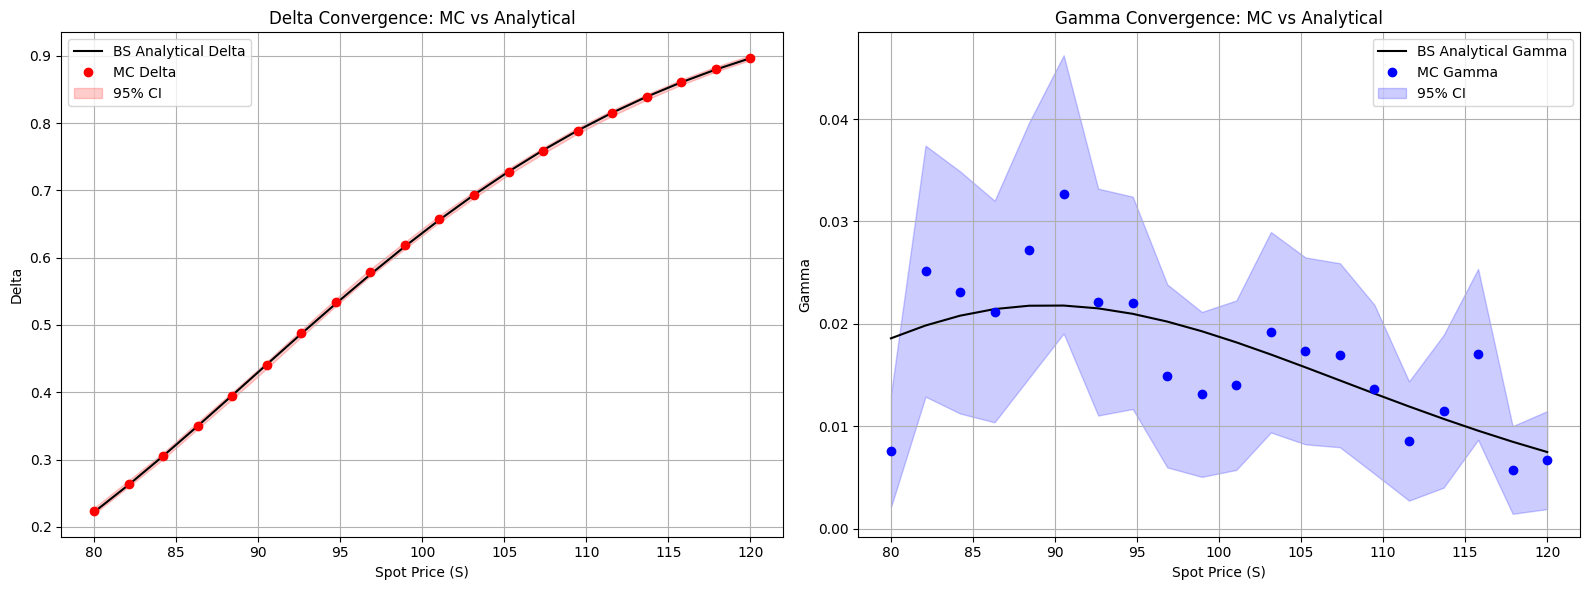

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.physics.simulator import GBMSimulator
from src.physics.analytics import BlackScholesAnalytical

# 1. Parameters
K = 100.0
T = 1.0
r = 0.05
sigma = 0.20
dt = 1/252  
n_paths = 50000
epsilon = 1e-2
seed = 42

S_range = np.linspace(80, 120, 20)

# 2. Vectorized Analytical Oracle
# The BlackScholesAnalytical class accepts the entire S_range array at once
bs_oracle = BlackScholesAnalytical(S_range, K, T, r, sigma)
bs_deltas = bs_oracle.call_delta()
bs_gammas = bs_oracle.call_gamma()

# 3. Vectorized Monte Carlo Engine
# Run ONE simulation with S0=1.0 to extract the pure stochastic growth factor
sim = GBMSimulator(seed)
paths_unit = sim.simulate_paths(s0=1.0, mu=r, sigma=sigma, T=T, dt=dt, n_paths=n_paths)
growth_factor = paths_unit[-1]  # Shape: (n_paths,)

# Reshape S_range into a column vector for broadcasting
S_col = S_range[:, np.newaxis]  # Shape: (20, 1)

# Broadcast terminal prices for all spot prices and bumps simultaneously
# Resulting matrices have shape: (20, n_paths)
terminal_up = (S_col + epsilon) * growth_factor
terminal_down = (S_col - epsilon) * growth_factor
terminal_base = S_col * growth_factor

# Vectorized Payoffs
payoffs_up = np.maximum(terminal_up - K, 0)
payoffs_down = np.maximum(terminal_down - K, 0)
payoffs_base = np.maximum(terminal_base - K, 0)

# Discounting
discount_factor = np.exp(-r * T)
disc_up = discount_factor * payoffs_up
disc_down = discount_factor * payoffs_down
disc_base = discount_factor * payoffs_base

# Finite Differences across the entire grid
pathwise_deltas = (disc_up - disc_down) / (2 * epsilon)
pathwise_gammas = (disc_up - 2 * disc_base + disc_down) / (epsilon ** 2)

# Aggregation (calculate mean and standard error across the paths, axis=1)
mc_deltas = np.mean(pathwise_deltas, axis=1)
mc_delta_errors = np.std(pathwise_deltas, axis=1, ddof=1) / np.sqrt(n_paths)

mc_gammas = np.mean(pathwise_gammas, axis=1)
mc_gamma_errors = np.std(pathwise_gammas, axis=1, ddof=1) / np.sqrt(n_paths)

# 4. Plot Results
z_score = 1.96 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Delta Plot ---
ax1.plot(S_range, bs_deltas, 'k-', label='BS Analytical Delta')
ax1.plot(S_range, mc_deltas, 'ro', label='MC Delta')
ax1.fill_between(
    S_range, 
    mc_deltas - z_score * mc_delta_errors, 
    mc_deltas + z_score * mc_delta_errors, 
    color='red', alpha=0.2, label='95% CI'
)
ax1.set_xlabel('Spot Price (S)')
ax1.set_ylabel('Delta')
ax1.set_title('Delta Convergence: MC vs Analytical')
ax1.legend()
ax1.grid(True)

# --- Gamma Plot ---
ax2.plot(S_range, bs_gammas, 'k-', label='BS Analytical Gamma')
ax2.plot(S_range, mc_gammas, 'bo', label='MC Gamma')
ax2.fill_between(
    S_range, 
    mc_gammas - z_score * mc_gamma_errors, 
    mc_gammas + z_score * mc_gamma_errors, 
    color='blue', alpha=0.2, label='95% CI'
)
ax2.set_xlabel('Spot Price (S)')
ax2.set_ylabel('Gamma')
ax2.set_title('Gamma Convergence: MC vs Analytical')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

<>:79: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:79: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\reymo\AppData\Local\Temp\ipykernel_27720\3881164310.py:79: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.xlabel('Bump Size ($\epsilon$) - Log Scale')


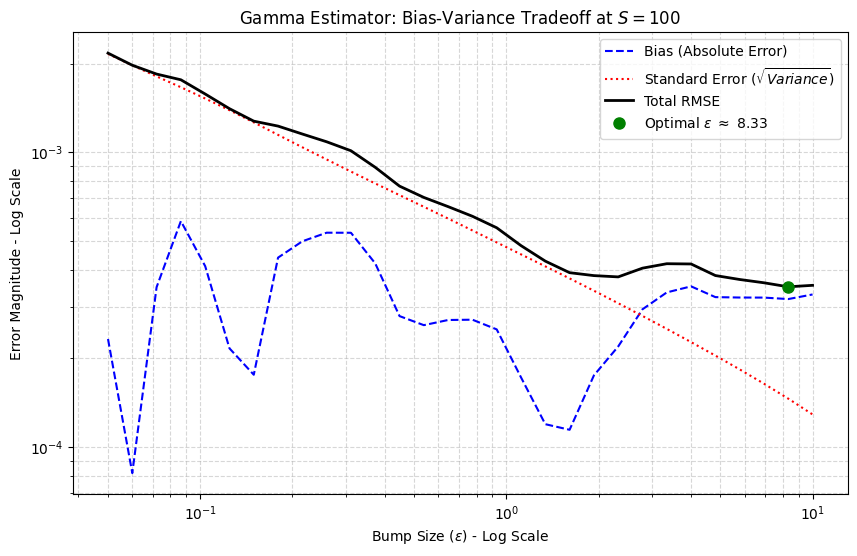

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.physics.simulator import GBMSimulator
# from src.analytics.black_scholes import BlackScholesAnalytical

# 1. Fixed ATM Parameters
S_atm = 100.0
K = 100.0
T = 1.0
r = 0.05
sigma = 0.20
dt = 1/252
n_paths = 50000
seed = 42

# 2. Define a range of epsilons to test (from 0.05 to 10.0)
epsilons = np.geomspace(0.05, 10.0, 30)

# 3. Get the analytical benchmark
bs_oracle = BlackScholesAnalytical(S_atm, K, T, r, sigma)
true_gamma = bs_oracle.call_gamma()

# 4. Run ONE base simulation
sim_base = GBMSimulator(seed)
path_base = sim_base.simulate_paths(s0=S_atm, mu=r, sigma=sigma, T=T, dt=dt, n_paths=n_paths)
terminal_base = path_base[-1]

# Extract the stochastic growth factor
growth_factor = terminal_base / S_atm  # Shape: (n_paths,)

# Reshape epsilons into a column vector for broadcasting
eps_col = epsilons[:, np.newaxis]      # Shape: (30, 1)

# Broadcast terminal prices for all epsilons instantly
# Shape will be (30, n_paths)
terminal_up = (S_atm + eps_col) * growth_factor
terminal_down = (S_atm - eps_col) * growth_factor

# 5. Vectorized Payoffs and Discounting
payoffs_up = np.maximum(terminal_up - K, 0)
payoffs_down = np.maximum(terminal_down - K, 0)
payoffs_base = np.maximum(terminal_base - K, 0) # Shape: (n_paths,)

discount_factor = np.exp(-r * T)
disc_up = discount_factor * payoffs_up
disc_down = discount_factor * payoffs_down
disc_base = discount_factor * payoffs_base

# 6. Vectorized Finite Differences
# Broadcasting subtracts the 1D disc_base from every row in the 2D arrays
pathwise_gammas = (disc_up - 2 * disc_base + disc_down) / (eps_col ** 2)

# Calculate mean and standard error across the paths (axis=1)
mc_gammas = np.mean(pathwise_gammas, axis=1)
mc_gamma_errors = np.std(pathwise_gammas, axis=1, ddof=1) / np.sqrt(n_paths)

# Calculate RMSE
biases = np.abs(mc_gammas - true_gamma)
variances = mc_gamma_errors ** 2
rmses = np.sqrt(biases ** 2 + variances)

# 7. Plot the Bias-Variance Tradeoff
plt.figure(figsize=(10, 6))

plt.plot(epsilons, biases, 'b--', label='Bias (Absolute Error)')
plt.plot(epsilons, np.sqrt(variances), 'r:', label=r'Standard Error ($\sqrt{Variance}$)')
plt.plot(epsilons, rmses, 'k-', linewidth=2, label='Total RMSE')

# Find and mark the optimal epsilon
optimal_idx = np.argmin(rmses)
optimal_eps = epsilons[optimal_idx]
min_rmse = rmses[optimal_idx]

plt.plot(optimal_eps, min_rmse, 'go', markersize=8, 
         label=rf'Optimal $\epsilon$ $\approx$ {optimal_eps:.2f}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Bump Size ($\epsilon$) - Log Scale')
plt.ylabel('Error Magnitude - Log Scale')
plt.title('Gamma Estimator: Bias-Variance Tradeoff at $S=100$')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

In [2]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import norm

# 1. Paramètres
K = 100.0
r = 0.05
sigma = 0.20

# 2. Création de la grille (Vectorisé)
time_steps = np.linspace(0.01, 1.0, 50)
spot_steps = np.linspace(80, 120, 50)
T_mesh, S_mesh = np.meshgrid(time_steps, spot_steps)

# 3. Calcul analytique du Charm
d1 = (np.log(S_mesh / K) + (r + 0.5 * sigma**2) * T_mesh) / (sigma * np.sqrt(T_mesh))
d2 = d1 - sigma * np.sqrt(T_mesh)

charm_mesh = -norm.pdf(d1) * ((r / (sigma * np.sqrt(T_mesh))) - (d2 / (2 * T_mesh)))

# 4. Rendu interactif avec Plotly
fig = go.Figure(data=[go.Surface(
    z=charm_mesh, 
    x=time_steps, 
    y=spot_steps,
    colorscale='Viridis',
    colorbar=dict(title="Charm")
)])

fig.update_layout(
    title='Analytical 3D Charm Surface',
    scene=dict(
        xaxis_title='Time to Maturity (T)',
        yaxis_title='Spot Price (S)',
        zaxis_title='Charm',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2) # Angle de vue initial par défaut
        )
    ),
    width=900,
    height=700,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()